# Objectif du notebook 

Date de création : 1102/2026

On traite ici le cas intermédiaire : la librairie est peuplée à l'aide de la source active et la source à localiser est une source passive (bruit de bateau). 

In [1]:
# %matplotlib notebook

import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import scipy.signal as sp 
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from datetime import timedelta, datetime
from scipy.stats import linregress
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [2]:
project_root = os.path.abspath(
    os.path.join(os.path.dirname(os.getcwd()), "..", "..", "..", "..")
)
root_groix_data = os.path.join(project_root, "data", "fiberscope_groix_oct_2025")
root_groix_wav = os.path.join(root_groix_data, "wav")
root_groix_metadata = os.path.join(root_groix_data, "metadata")

root_folder = os.path.join(project_root, "real_data_analysis", "fiberscope_groix")
data_folder = os.path.join(root_folder, "data")
img_folder = os.path.join(root_folder, "img")

rtf_mfp_img_folder = os.path.join(img_folder, "rtf_mfp", "library_active_trailed_event_passive")

In [3]:
sys.path.append(project_root)
from publication.publication_figure import (
    PubFigure,
    LargeFigure,
    color,
    set_subfigures_abc_labels,
)
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_utils import (
    get_dists_2_passive_event,
    get_dists_2,
    get_dists,
    derive_doppler_jules,
)
from real_data_analysis.fiberscope_groix.src.fiberscope_groix_manager import (
    ActiveFiberscopeManager,
    PassiveFiberscopeManager,
    BandFilter,
)

# Chargement des données 

In [4]:
# Load GPS dataset for station coordinates
ds_gps = xr.open_dataset(os.path.join(data_folder, "gps.nc"))
# Load AIS
ds_ais = xr.open_dataset(os.path.join(data_folder, "ais.nc"))


# Load arrivals dataset
fpath = os.path.join(
    data_folder,
    f"processed_arrivals.nc",
)
ds_arr = xr.open_dataset(fpath)
df_arr = ds_arr.to_dataframe()

# Construction de la librairie de répliques 

In [5]:
# Libraries composer des vecteurs construits à partir de la séquence tractée
library_sequence = 144
df_library = df_arr.loc[df_arr["sequence_id"] == library_sequence]

## Calcul des répliques (RTF)

In [6]:
bandfilter = BandFilter(
    order=4,
    lowcut=200,
    highcut=990,
)
# bandfilter = None

rtf_estimator = "cs-evd"

h_index_ref = 1  # -> OBS 3 has the higher snr
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = False
process_pulse_one_by_one = True
estimate_ir_duration = False

tau_ir_hat = 0.2  # estimated impulse response duration from sequence 144
tau_ir_hat *= 2  # To ensure we include the entire response 
# tau_rtf_analysis = 10 * tau_ir_hat  # To ensure we include the entire response
tau_rtf_analysis = 3

fs = 2000
# Number of samples corresponding to the assumed impulse response duration
n_rtf_analysis = int(tau_rtf_analysis * fs)
# Get closer power of 2
nperseg = 2 ** int(
    np.log2(n_rtf_analysis) + 1
)  # Number of sample per snapshot to use = closest power of two
alpha_overlap = 0.75
noverlap = int(nperseg * alpha_overlap)

print(f"tau = {tau_rtf_analysis}s")
print(f"nperseg = {nperseg} ({nperseg * 1/fs}s), noverlap = {noverlap}")

fsm = ActiveFiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=bandfilter,
    tau_ir=tau_ir_hat,
    process_pulse_one_by_one=process_pulse_one_by_one,
    estimate_ir_duration=estimate_ir_duration,
    rtf_estimator=rtf_estimator,
    verbose=False,
)

fsm.nperseg = nperseg
fsm.noverlap = noverlap

# fsm.process_analysis(
#     df_arrivals=df_library,
#     set_stft_props=False,
# )

tau = 3s
nperseg = 8192 (4.096s), noverlap = 6144


# Source event à localiser : Jules passant proche de l'OBS 3

In [7]:
# Define the period of interest
t_start = datetime(year=2025, month=10, day=15, hour=10, minute=8, second=00)
t_end = datetime(year=2025, month=10, day=15, hour=11, minute=32, second=00)
print(t_start, t_end)

2025-10-15 10:08:00 2025-10-15 11:32:00


In [8]:
root_fig = os.path.join(rtf_mfp_img_folder, f"{datetime.strftime(t_start, fsm.datetime_fmt)}_to_{datetime.strftime(t_end, fsm.datetime_fmt)}")
if not os.path.exists(root_fig):
    os.makedirs(root_fig)

[228000210, 227814270, 226916000, 227315990, 228121530]


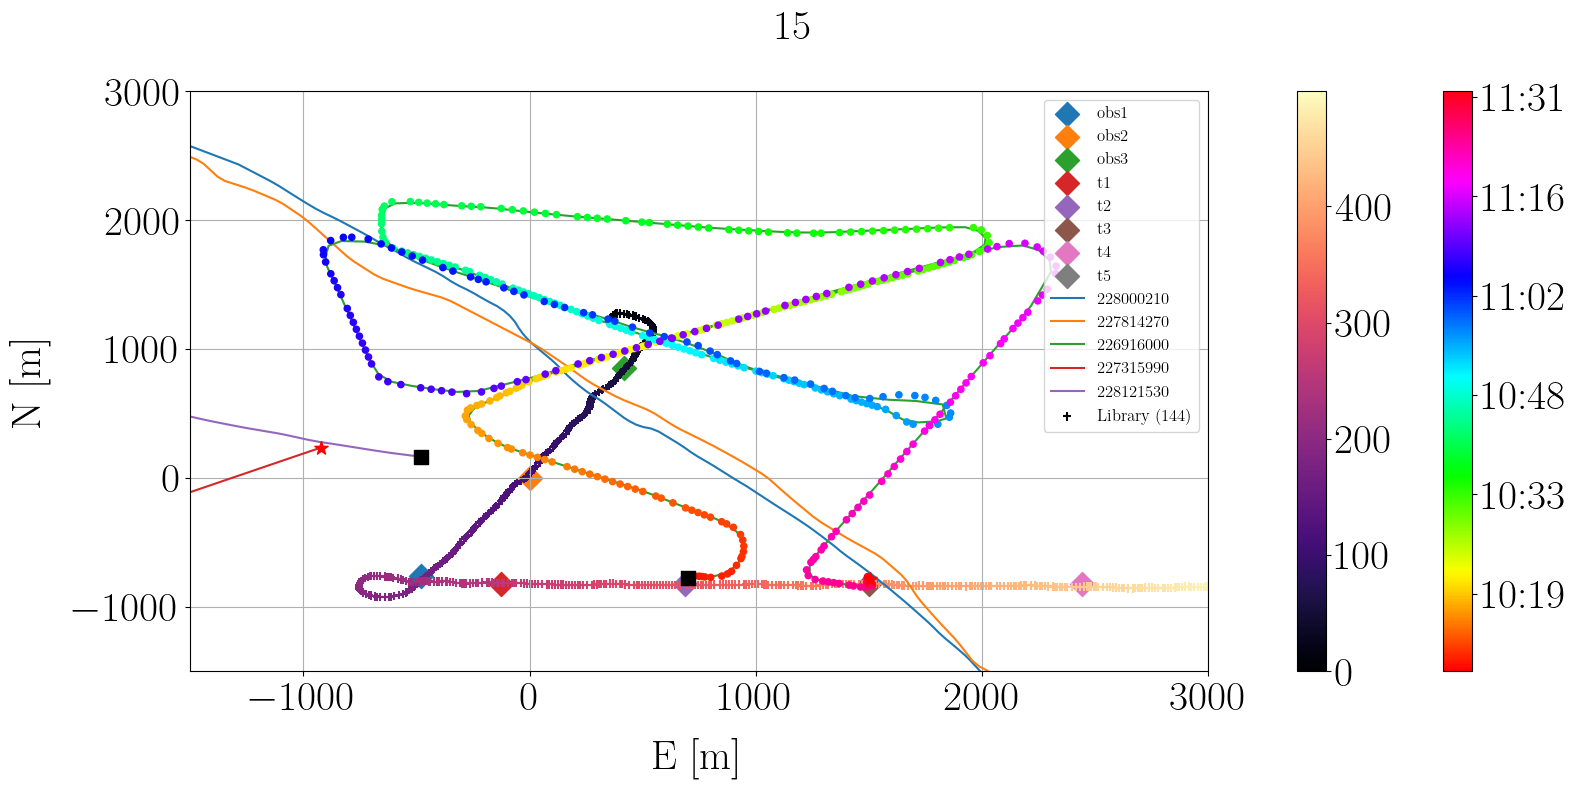

In [9]:
gps_event = ds_gps.sel(time=slice(t_start, t_end))
ais_event = ds_ais.sel(time=slice(t_start, t_end))


# Filter AIS data in area

e_min = -1000
e_max = +1000
n_min = -1000
n_max = +1000

mmsi_in_box = []
for mmsi in ds_ais.mmsi.values:
    ship = ais_event.sel(mmsi=mmsi)
    ship_in_e_range = np.logical_and(ship.e.values >= e_min, ship.e.values <= e_max)
    ship_in_n_range = np.logical_and(ship.n.values >= n_min, ship.n.values <= n_max)
    ship_in_box = np.logical_and(ship_in_e_range, ship_in_n_range)

    if np.any(ship_in_box):
        mmsi_in_box.append(mmsi)

print(mmsi_in_box)
ais_event = ais_event.sel(mmsi=mmsi_in_box)


# gps_day = gps_day.isel(time=slice(3700, 4100))
# print(f"{gps_day.time.min().values}, {gps_day.time.max().values}")
fig, ax = plt.subplots(1, 1, figsize=(16, 8), sharex=False, sharey=False)
fig.suptitle(f"{str(t_start.day)}")

keys = ["obs1", "obs2", "obs3", "t1", "t2", "t3", "t4", "t5"]
for k in keys:
    e = ds_gps.attrs[f"{k}_e_apriori"]
    n = ds_gps.attrs[f"{k}_n_apriori"]
    ax.scatter(
        e,
        n,
        marker="D",
        label=k,
        zorder=1,
        s=150,
    )

times = mdates.date2num(gps_event.time)
im = ax.scatter(
    gps_event.e,
    gps_event.n,
    c=times,
    s=20,
    cmap="hsv",
    zorder=4,
)
cbar = plt.colorbar(im)
cbar.ax.yaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

# Add ships in the area using AIS
for mmsi in ais_event.mmsi.values:
    ship = ais_event.sel(mmsi=mmsi)
    plt.plot(ship.e.values, ship.n.values, label=mmsi)
    plt.scatter(ship.e.values[0], ship.n.values[0], marker="s", s=100, color="k", zorder=5)
    plt.scatter(
        ship.e.values[-1], ship.n.values[-1], marker="*", s=100, color="r", zorder=5
    )


# Série de positions successives
im = plt.scatter(
    df_library["emission_interp_e_gps"],
    df_library["emission_interp_n_gps"],
    marker="+",
    label=f"Library ({library_sequence})",
    c=np.arange(df_library["emission_interp_e_gps"].size),
    cmap="magma",
)
cbar = plt.colorbar(im)

plt.xlim(-1500, 3000)
plt.ylim(-1500, 3000)

ax.legend(fontsize=12)
ax.grid()
ax.set_title("")
ax.set_xlabel("E [m]")
ax.set_ylabel("N [m]")

fpath = os.path.join(root_fig, "situation_ais_gps.png")
plt.savefig(fpath)

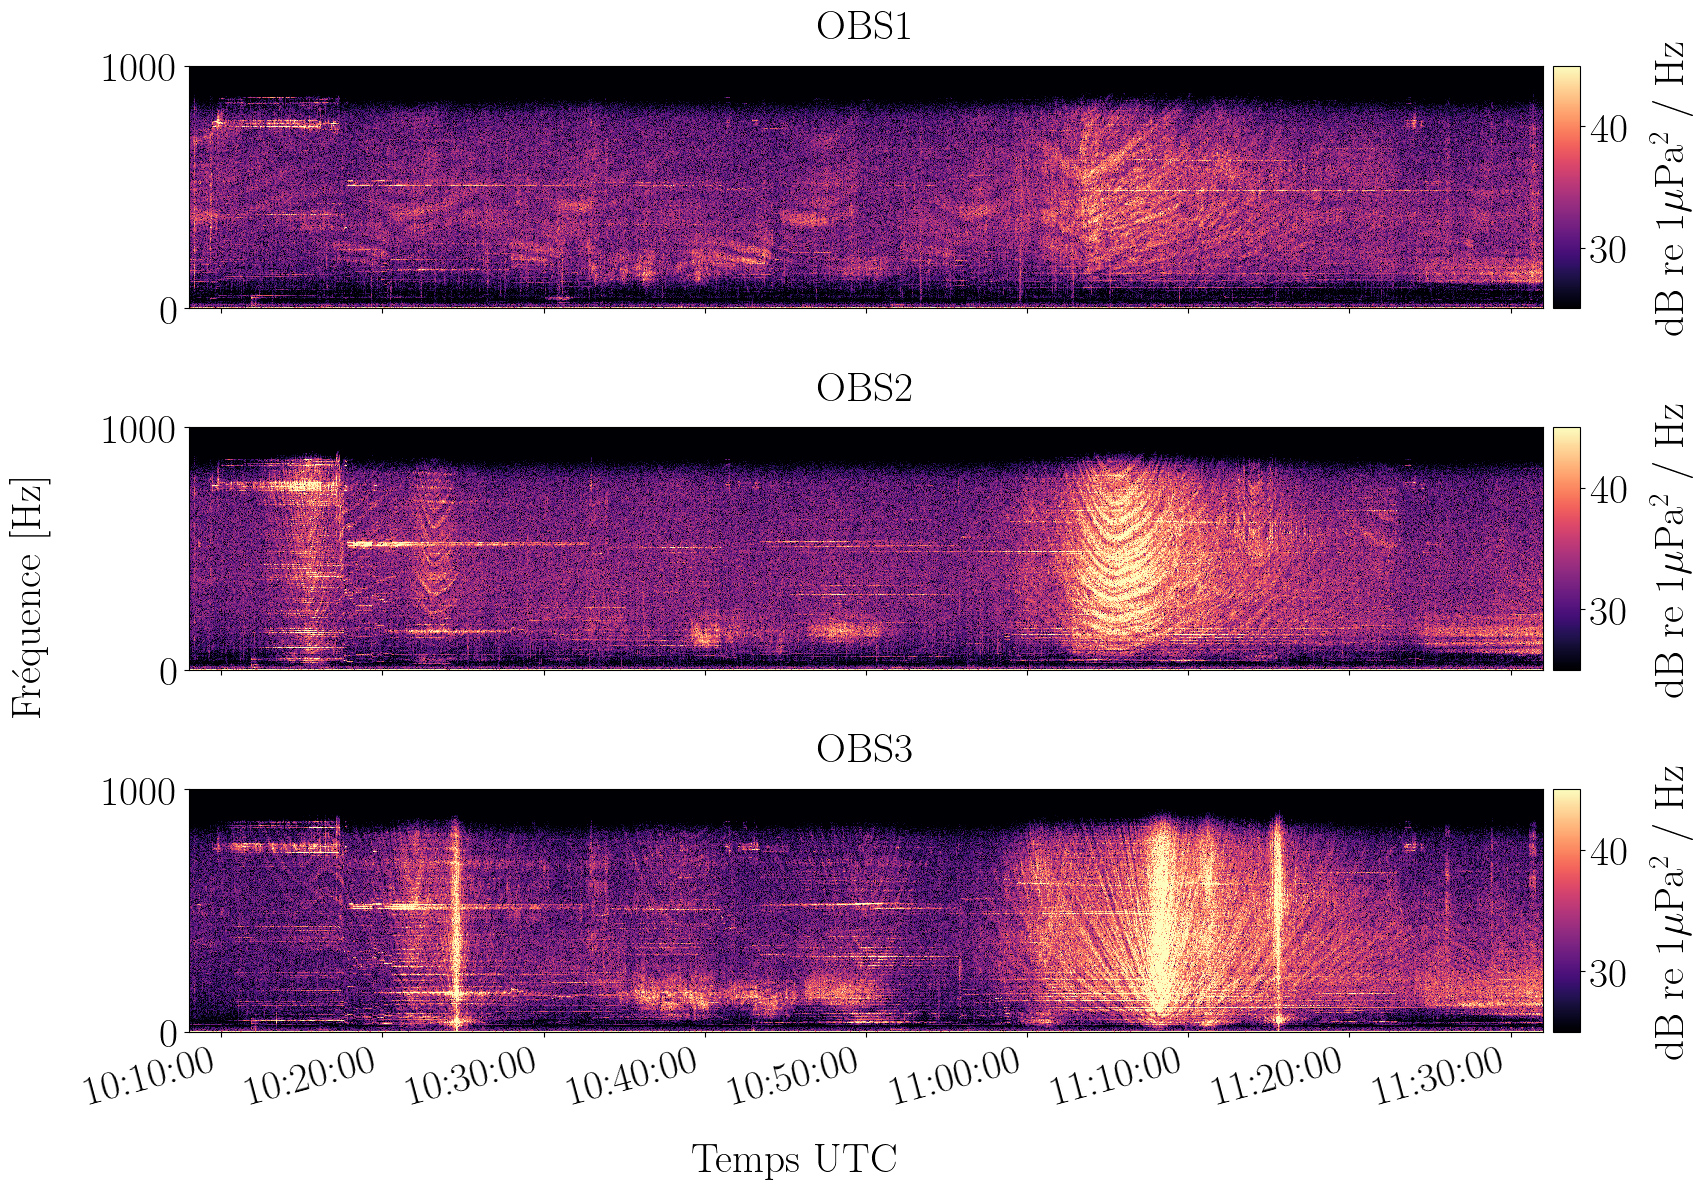

In [10]:
# Load wav data and plot the corresponding sequence
ds_wav = xr.open_dataset(os.path.join(data_folder, "channel_H_wav.nc"))

# Paramètre STFT
nperseg = 2**12
noverlap = 2**11

fig, axs = plt.subplots(3, 1, sharex=True, figsize=(16, 12))
axs = np.atleast_1d(axs)

for i, obs_id in enumerate([1, 2, 3]):

    datetime_fmt = ds_wav.attrs["datetime_format"]

    sig_varname = f"signal_obs{obs_id}"
    time_coordsname = f"time{obs_id}"
    signal = ds_wav[sig_varname]

    # Select a window of the signal
    fs = ds_wav.attrs[f"fs_obs{obs_id}"]

    # Start of recording
    t0 = ds_wav.attrs[f"start_datetime_obs{obs_id}"]
    t0 = datetime.strptime(t0, datetime_fmt)

    # Select window
    t_from_t0_start_s = (t_start - t0).total_seconds()
    n_start = int(t_from_t0_start_s * fs)
    t_from_t0_end_s = (t_end - t0).total_seconds()
    n_end = int(t_from_t0_end_s * fs)

    # Slice signal
    sig_win = signal.isel({time_coordsname: slice(n_start, n_end)})

    # Define datetime borders
    t0_slice = t0 + timedelta(seconds=n_start * 1 / fs)
    t1_slice = t0 + timedelta(seconds=n_end * 1 / fs)

    # Derive stft
    ff, tt, stft = sp.stft(
        sig_win.values,  # .values -> ici on charge les données en mémoire (un tout petit subset seulement)
        fs=fs,
        window="hann",
        nperseg=nperseg,
        noverlap=noverlap,
        scaling="psd",  # U^2 / Hz
    )
    sxx = 10 * np.log10(np.abs(stft))  # dB re 1uPa**2 / Hz ou dB re 1 (m/s)^2 / Hz
    # Associated datetime vector
    tt_datetime = pd.date_range(
        t0_slice,
        t0_slice + timedelta(seconds=tt[-1]),
        freq=f"{tt[1]-tt[0]}s",
        inclusive="both",
    )

    # Plot
    cmap = "magma"
    # vmin = np.percentile(sxx, 10)
    # vmax = np.percentile(sxx, 99)
    vmin = 25
    vmax = 45

    im = axs[i].pcolormesh(tt_datetime, ff, sxx, cmap=cmap, vmin=vmin, vmax=vmax)

    clabel = r"dB re 1$\mu$Pa$^2$ / Hz"
    divider = make_axes_locatable(axs[i])
    cax = divider.append_axes("right", size="2%", pad=0.10)
    fig.colorbar(im, cax=cax, orientation="vertical", label=clabel)

    # axs[ich].colorbar(im, label=clabel)

    axs[i].set_title(f"OBS{obs_id}")

formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
formatter = mdates.DateFormatter("%H:%M:%S")
axs[-1].xaxis.set_major_formatter(formatter)
locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
axs[-1].xaxis.set_major_locator(locator)
plt.setp(axs[-1].get_xticklabels(), rotation=15, ha="right")


# nticks = 10
# xmin, xmax = axs[-1].get_xlim()
# axs[-1].set_xticks(np.linspace(xmin, xmax, nticks))
# plt.setp(axs[-1].get_xticklabels(), rotation=25, ha="center")

fig.supylabel("Fréquence [Hz]")
fig.supxlabel("Temps UTC")
# fig.suptitle(f"OBS{obs_id}")

fpath = os.path.join(root_fig, "spectro_3obs.png")
plt.savefig(fpath, bbox_inches="tight")

In [11]:
gps_event.time.attrs["long_name"] = "Temps UTC" 

spatial_dist = {}
spatial_dist_ais = {mmsi: {} for mmsi in ais_event.mmsi.values}

for pulse_id in df_library["pulse_id"].unique():
    df_lib_pulse_i = df_library.loc[df_library["pulse_id"] == pulse_id].iloc[0]

    lib_pos_e = df_lib_pulse_i["emission_interp_e_gps"]
    lib_pos_n = df_lib_pulse_i["emission_interp_n_gps"]

    # Compute distance
    # GPS
    spatial_dist_i = np.sqrt(
        (lib_pos_e - gps_event.e) ** 2 + (lib_pos_n - gps_event.n) ** 2
    )

    spatial_dist_i.attrs["long_name"] = "Distance"
    spatial_dist[pulse_id] = spatial_dist_i

    # AIS
    for mmsi in ais_event.mmsi.values:
        ship = ais_event.sel(mmsi=mmsi)

        dist_i_ais = np.sqrt(
            (lib_pos_e - ship.e) ** 2 + (lib_pos_n - ship.n) ** 2
        )
        dist_i_ais.attrs["long_name"] = "Distance"
        spatial_dist_ais[mmsi][pulse_id] = dist_i_ais

In [12]:
spatial_dist_mat = np.array(
    [spatial_dist[pulse_id].values for pulse_id in df_library["pulse_id"].unique()]
)

ds_spatial_dist = xr.Dataset(
    data_vars=dict(spatial_dist=(["pulse_id", "time"], spatial_dist_mat)),
    coords=dict(time=gps_event.time, pulse_id=df_library["pulse_id"].unique()),
)
ds_spatial_dist["spatial_dist"].attrs = {"units": "m", "long_name": "Distance"}
ds_spatial_dist["pulse_id"].attrs = {"long_name": "Pulse ID"}

In [13]:
spatial_dist_ais_mat = []
for i, mmsi in enumerate(ais_event.mmsi.values):
    d_mmsi = []
    for j, pulse_id in enumerate(df_library["pulse_id"].unique()):
        d_mmsi.append(spatial_dist_ais[mmsi][pulse_id].values)
    spatial_dist_ais_mat.append(d_mmsi)

spatial_dist_ais_mat = np.array(spatial_dist_ais_mat)
# spatial_dist_ais_mat.shape

ds_spatial_dist_ais = xr.Dataset(
    data_vars=dict(spatial_dist=(["mmsi", "pulse_id", "time"], spatial_dist_ais_mat)),
    coords=dict(
        mmsi=ais_event.mmsi.values,
        time=gps_event.time,
        pulse_id=df_library["pulse_id"].unique(),
    ),
)
ds_spatial_dist_ais["spatial_dist"].attrs = {"units": "m", "long_name": "Distance"}
ds_spatial_dist_ais["pulse_id"].attrs = {"long_name": "Pulse ID"}
ds_spatial_dist_ais["mmsi"].attrs = {"long_name": "MMSI"}

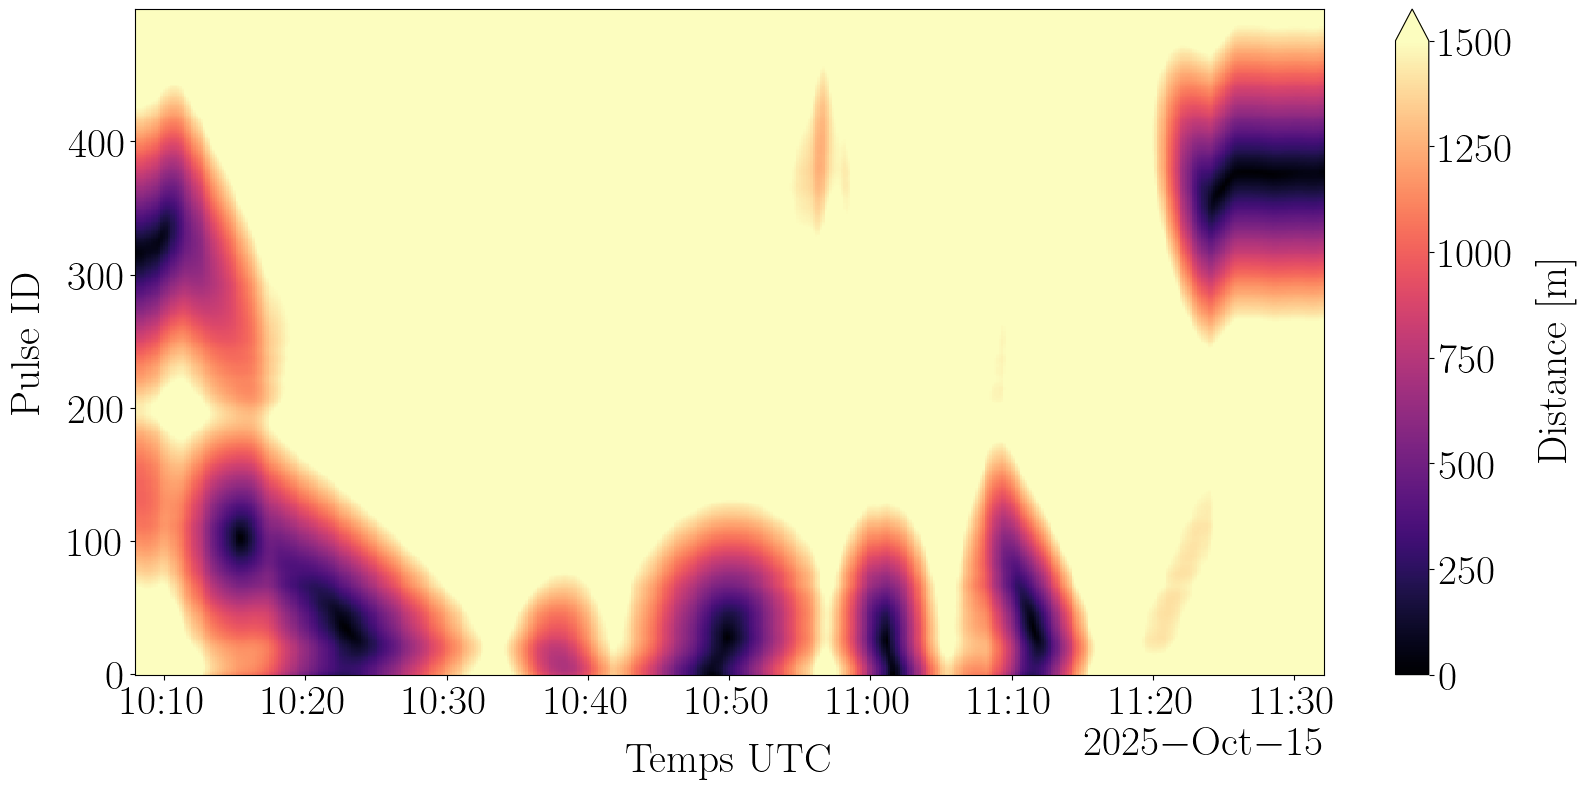

In [14]:
ds_spatial_dist.spatial_dist.plot(x="time", y="pulse_id", cmap="magma", vmin=0, vmax=1500)

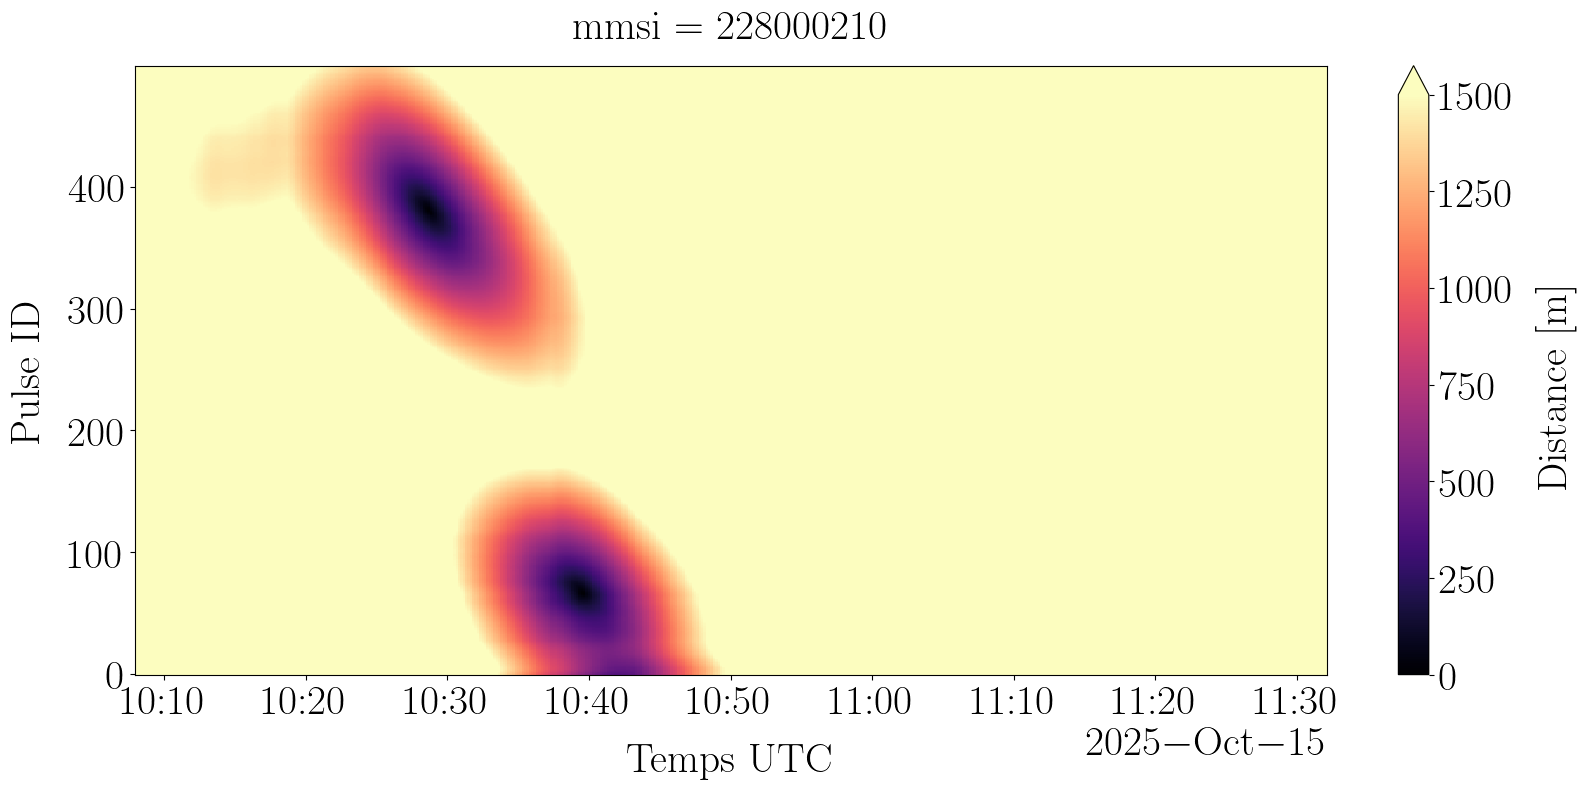

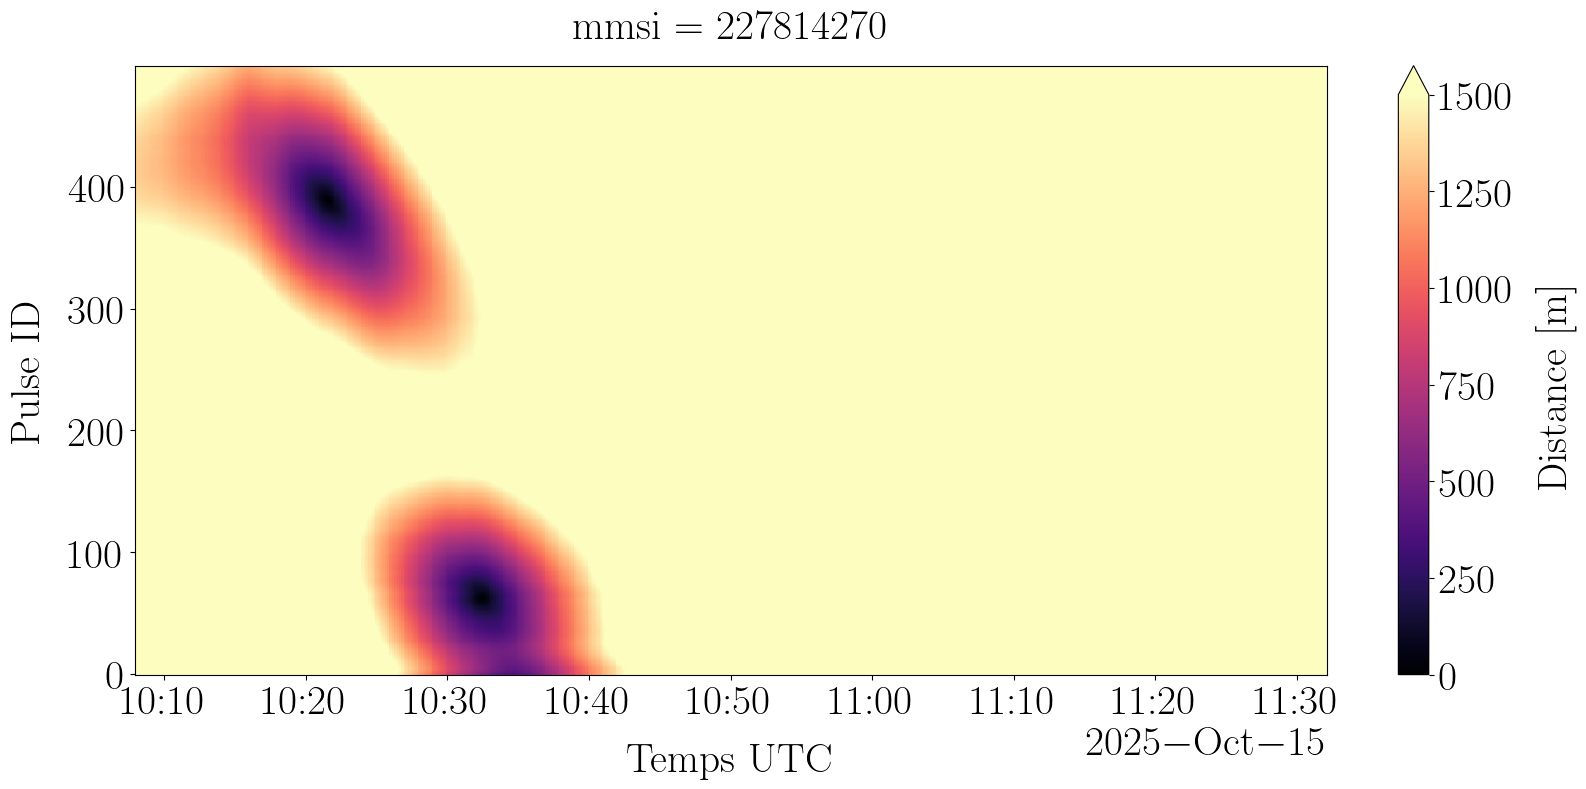

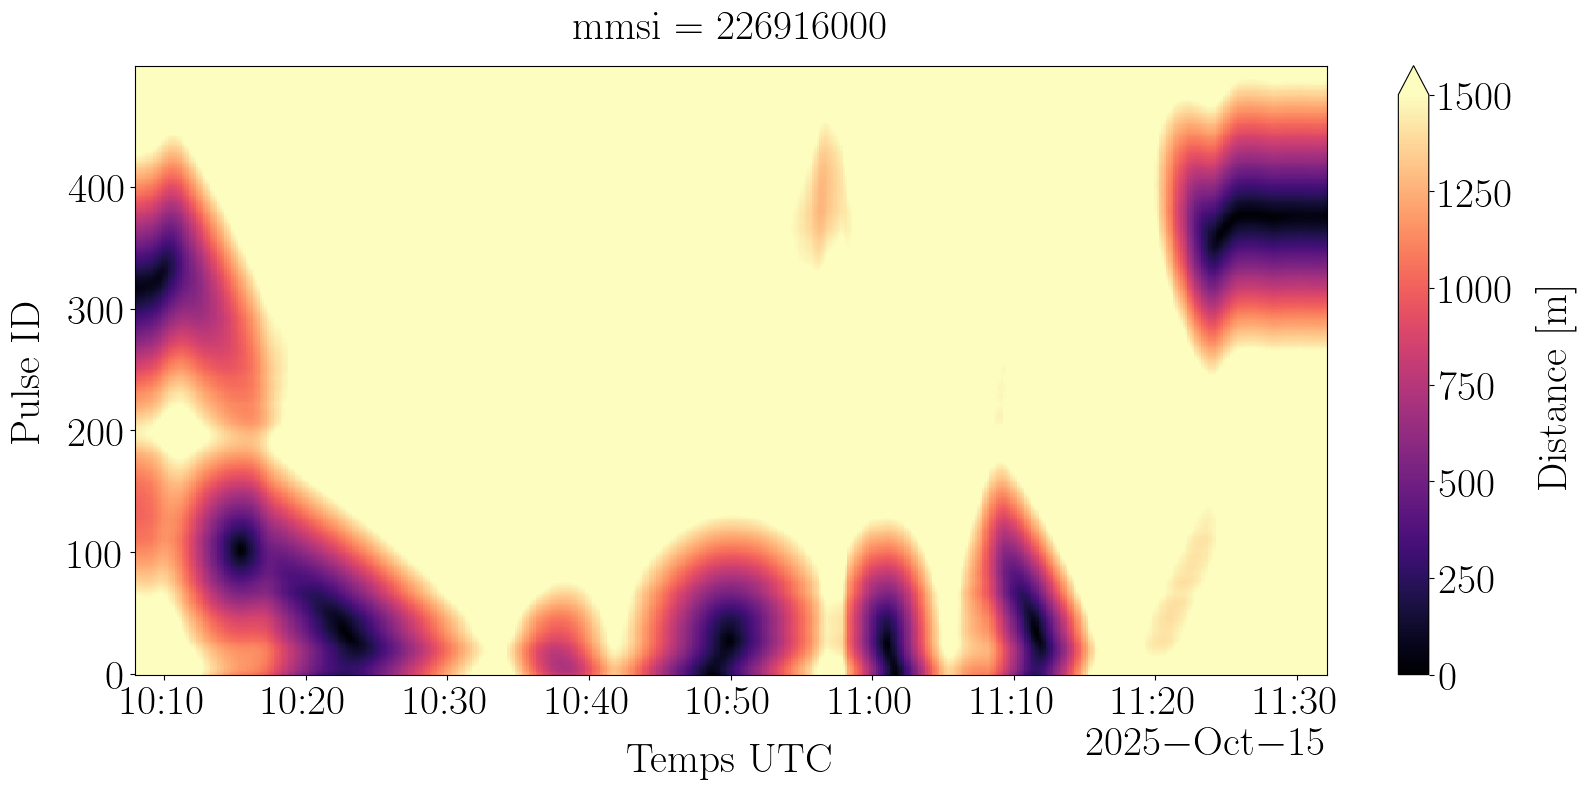

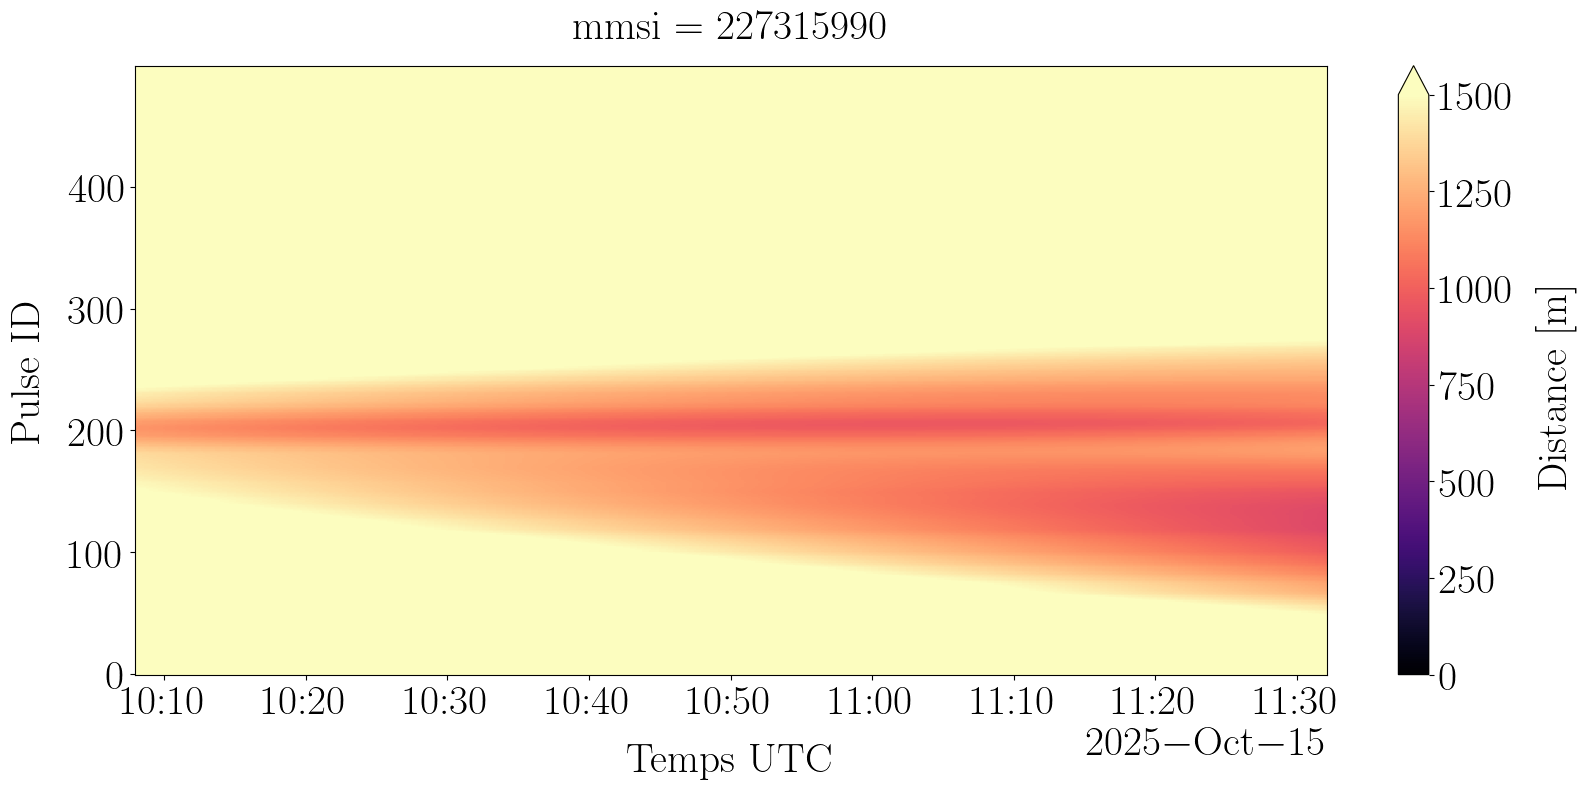

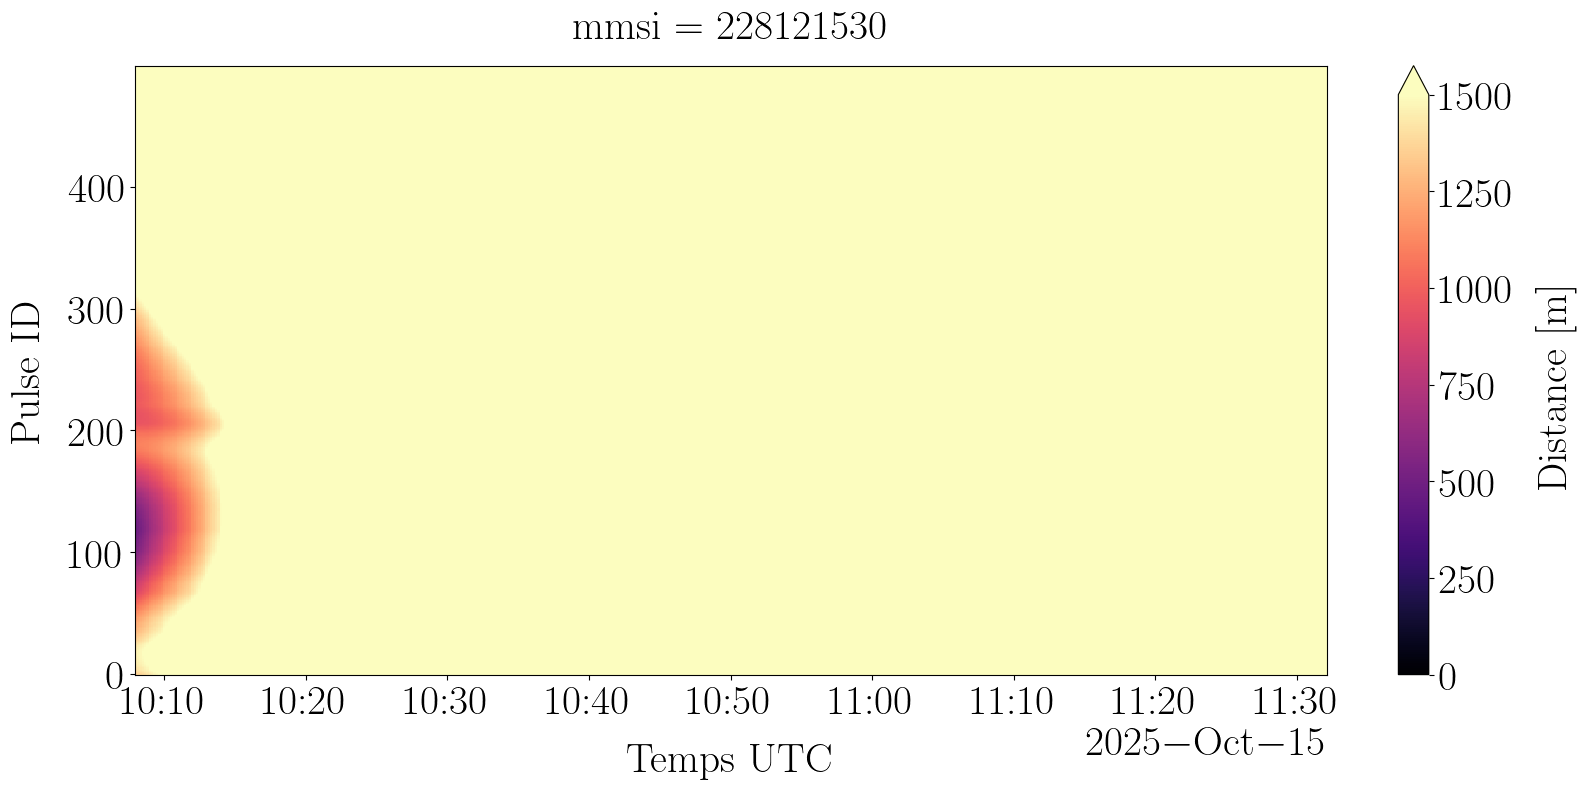

In [15]:
for mmsi in ds_spatial_dist_ais.mmsi.values:
    plt.figure()
    ds_spatial_dist_ais.sel(mmsi=mmsi).spatial_dist.plot(
        x="time", y="pulse_id", cmap="magma", vmin=0, vmax=1500
    )

In [16]:
fs = 2000
tau_rtf_analysis = 3

# Number of samples corresponding to the assumed impulse response duration
n_rtf_analysis = int(tau_rtf_analysis * fs)
# Get closer power of 2
nperseg = 2 ** int(
    np.log2(n_rtf_analysis) + 1
)  # Number of sample per snapshot to use = closest power of two
alpha_overlap = 0.75
noverlap = int(nperseg * alpha_overlap)


# h_index_ref = 1  # -> OBS 3 has the higher snr
# root_rtf_data = os.path.join(data_folder, "rtf")
plot_feature = False
process_pulse_one_by_one = True
estimate_ir_duration = False

fsm = PassiveFiberscopeManager(
    root_processed_data=data_folder,
    h_index_ref=h_index_ref,
    plot_feature=plot_feature,
    bandfilter=None,
    tau_ir=tau_ir_hat,
    process_pulse_one_by_one=process_pulse_one_by_one,
    estimate_ir_duration=estimate_ir_duration,
    rtf_estimator=rtf_estimator,
    verbose=False,
)

fsm.nperseg = nperseg
fsm.noverlap = noverlap

# # Comment below if already computed
# fsm.process_analysis(
#     ds_wav,
#     t_start,
#     t_end,
#     set_stft_props=False,
# )

# Compute ambiguity distance 

In [17]:
# Analyse rtf variations
fmin = 80      
fmax = 400

seq_library = df_library["sequence_id"].unique()
# seq_event = df_event["sequence_id"].unique()[0]

In [18]:
spatial_dist_obs = {}
theta_dist_obs = {}

theta_dist, spatial_dist, xr_seq_ref, df_seq_ref, xr_passive = (
    get_dists_2_passive_event(
        fsm=fsm,
        df_arr=df_arr,
        seq_id_ref=library_sequence,
        ds_gps=gps_event,
        t_start=t_start,
        t_end=t_end,
        fmin=fmin,
        fmax=fmax,
        dist_type="hermitian_angle",
    )
)

# idx_segment_min = np.argmin(theta_dist, axis=1)
# theta_dist = np.array(
#     [theta_dist[i, idx_segment_min[i]] for i in range(theta_dist.shape[0])]
# )
# spatial_dist = np.array(
#     [spatial_dist[i, idx_segment_min[i]] for i in range(spatial_dist.shape[0])]
# )

# theta_dist, spatial_dist, xr_seq, df_seq = get_dists(
#     fsm=fsm, df_arr=df_arr, seq_id_ref=seq_id_ref, seq_id=seq_event, fmin=fmin, fmax=fmax
# )

# # Store in dict
# theta_dist_obs[src_pos] = {
#     "id": seq_id_ref,
#     "theta": theta_dist
# }
# spatial_dist_obs[src_pos] = {"id": seq_id_ref, "r": spatial_dist}


Compute distance using hermitian angle distance (in C^N)


In [19]:
segment_dt = xr_passive.segment_dt.values
# Convert to datetime objects
segment_dt = pd.to_datetime(segment_dt).to_pydatetime()

segment_dt.shape

(1006,)

In [20]:
ds_theta_dist = xr.Dataset(
    data_vars=dict(theta=(["segment_dt", "pulse_id"], theta_dist)),
    coords=dict(segment_dt=segment_dt, pulse_id=xr_seq_ref.pulse_id.values),
)
ds_theta_dist["theta"].attrs = {
    "units": "°",
    "long_name": r"$\theta$",
}
ds_theta_dist["pulse_id"].attrs = {"long_name": "Pulse ID"}

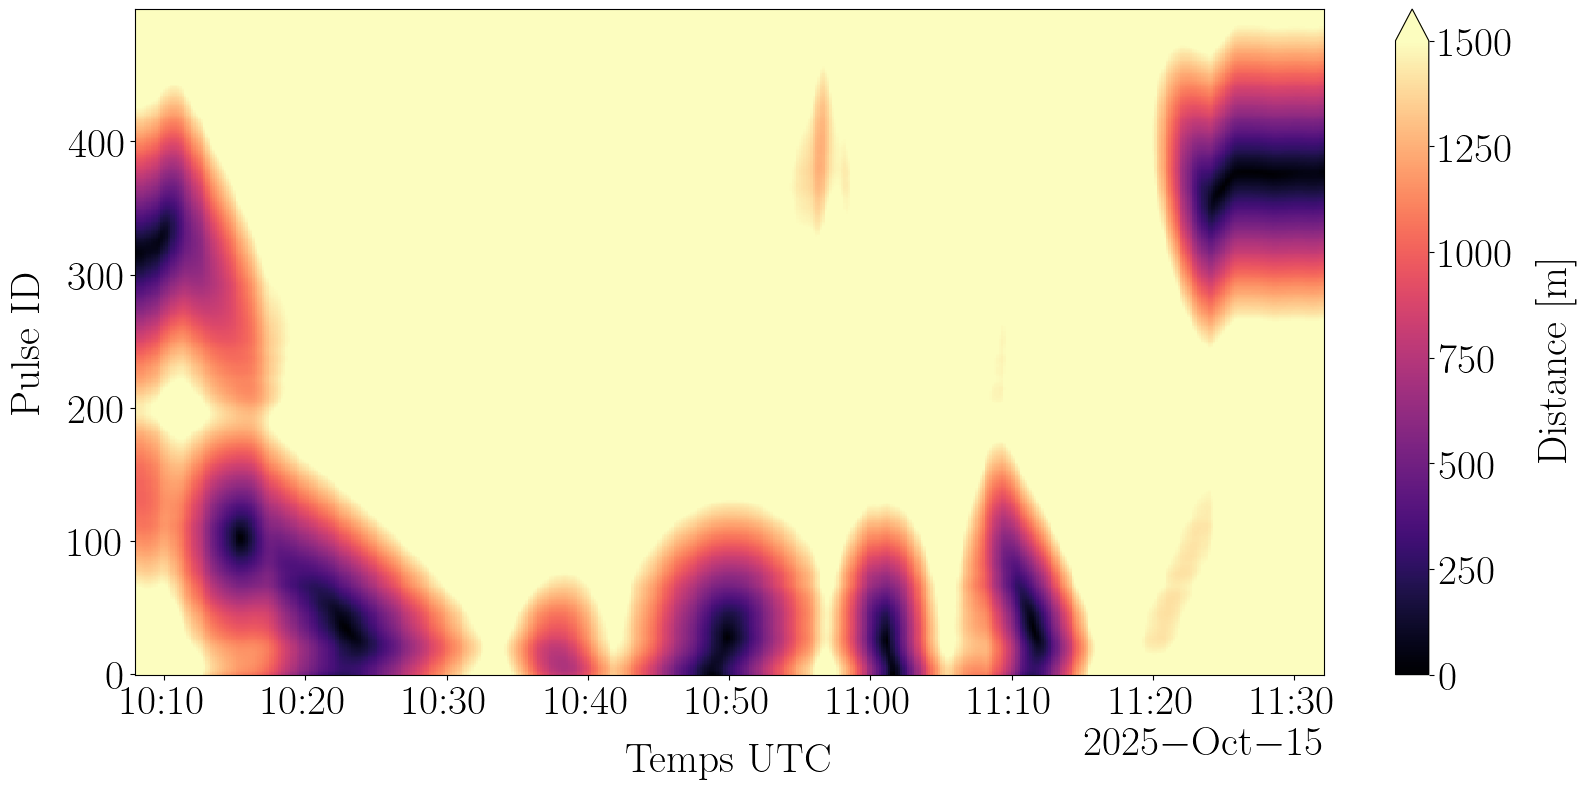

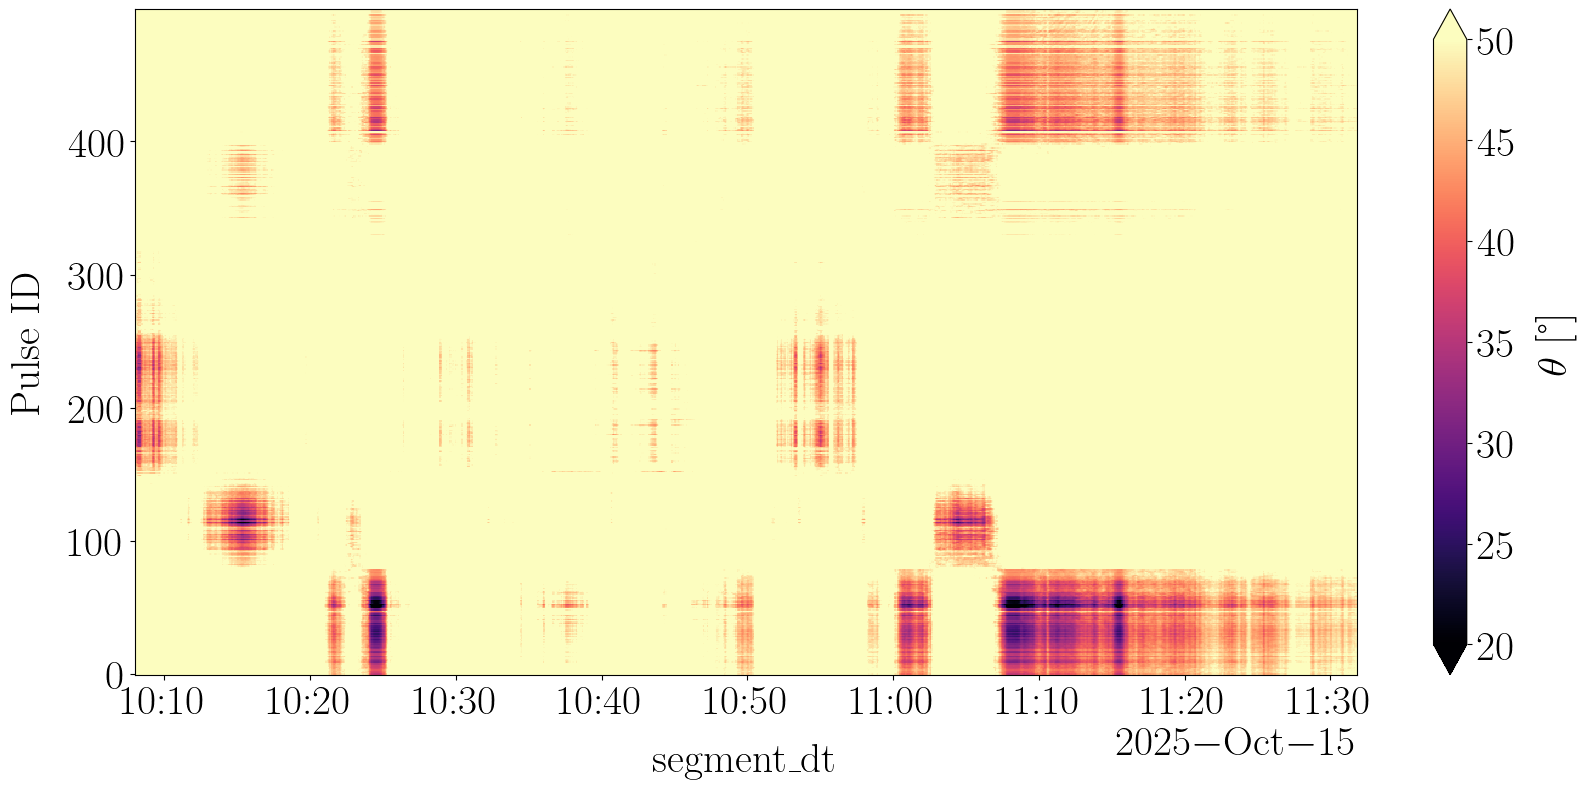

In [21]:
plt.figure()
ds_spatial_dist.spatial_dist.plot(
    x="time", y="pulse_id", cmap="magma", vmin=0, vmax=1500
)
plt.figure()

ds_theta_dist.theta.plot(x="segment_dt", y="pulse_id", vmin=20, vmax=50, cmap="magma")

In [22]:
# theta_distances = (90 - ds_theta_dist.theta) / 90
# max_at_each_seg = np.max(ds_theta_dist.theta.values, axis=1)[:, np.newaxis]
max_at_each_seg = np.percentile(ds_theta_dist.theta.values, 50, axis=1)[:, np.newaxis]

theta_distances = (max_at_each_seg - ds_theta_dist.theta) / max_at_each_seg
theta_distances = np.clip(theta_distances, 0, 1)

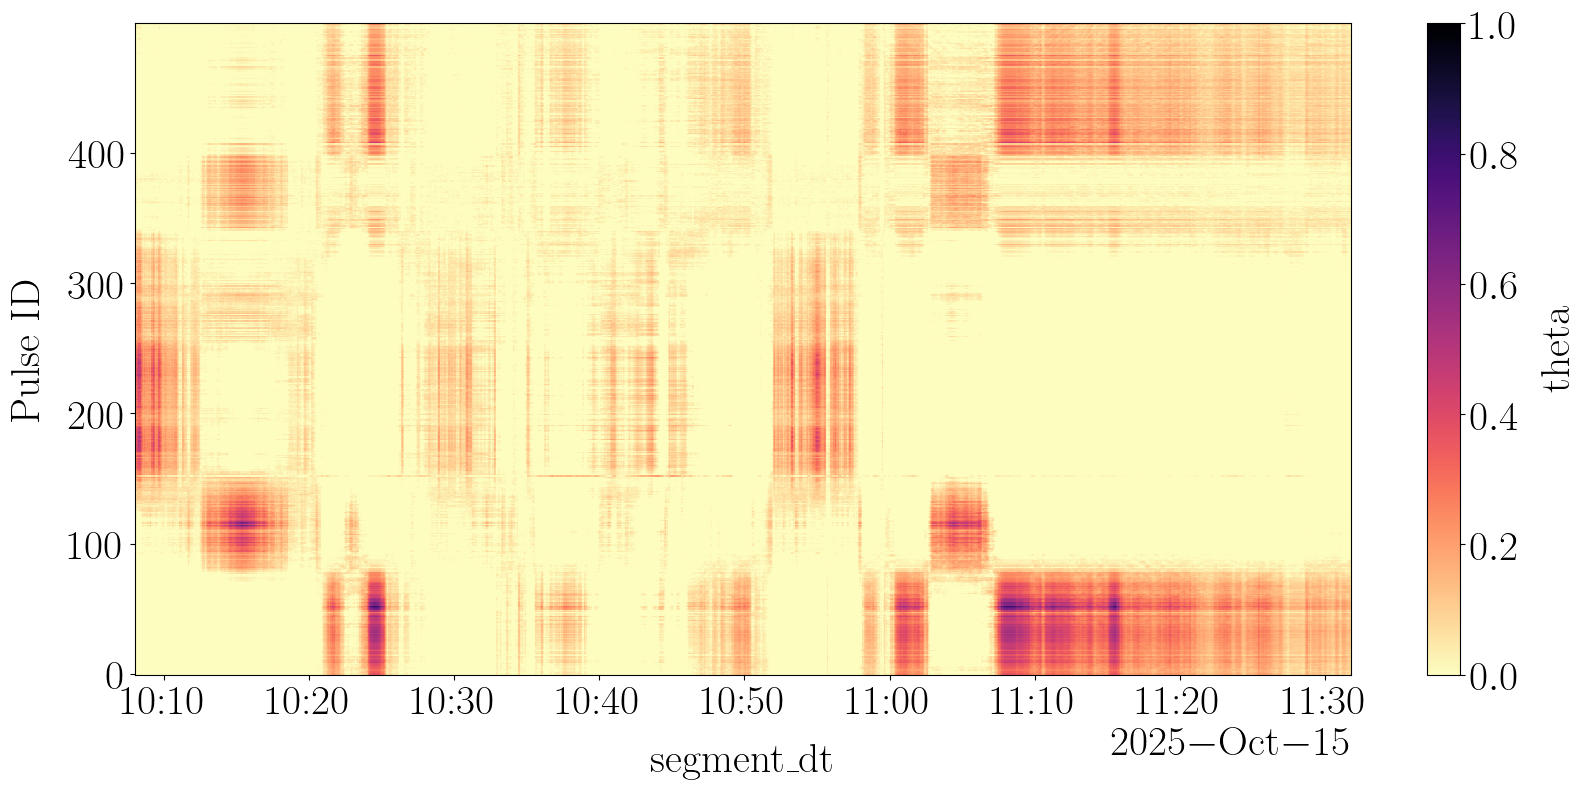

In [23]:
theta_distances.plot(x="segment_dt", y="pulse_id", vmin=0, vmax=1, cmap="magma_r")

In [24]:
# mu = theta_distances / np.sum(theta_distances, axis=1)
# mu.plot(x="segment_dt", y="pulse_id", vmin=0, vmax=1, cmap="magma_r")

In [25]:
# fpath = os.path.join(root_fig, "theta_dist_passive_event.nc")
# ds_theta_dist.to_netcdf(fpath)

In [26]:
from real_data_analysis.fiberscope_groix.src.localisation.rtf.rtf_mfp_animation_utils import rtf_mfp_animation


In [28]:
rtf_mfp_animation(
    ds_theta=ds_theta_dist,
    df_library=df_library,
    ds_gps_event=gps_event,
    ds_ais_event=ais_event,
    normalization_percentile=50,
    step=10,
    save=True,
    output_fname="rtf_mfp_localisation",
    fps=10,
    dpi=100,
    root_img=root_fig,
)

MovieWriter ffmpeg unavailable; using Pillow instead.
